# 1. Import Libraries

In [114]:
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_val_score,
    learning_curve,
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# 2. Load Dataset

In [115]:
df = pd.read_csv("laptop_price.csv", encoding="latin1")

# 3. Dataset Overview

In [116]:
print("Shape of Dataset :", df.shape)
display(df.head())
df.info()
display(df.describe().T)
print("Duplicate Rows :", df.duplicated().sum())

Shape of Dataset : (1303, 13)


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


,count,mean,std,min,25%,50%,75%,max
laptop_ID,1303.0,660.155794,381.172104,1.0,331.5,659.0,990.50,1320.0
Inches,1303.0,15.017191,1.426304,10.1,14.0,15.6,15.60,18.4
Price_euros,1303.0,1123.686992,699.009043,174.0,599.0,977.0,1487.88,6099.0


Duplicate Rows : 0


# 4. Remove Unwanted Columns

In [117]:
unnamed = [col for col in df.columns if "Unnamed" in col]
if unnamed:
    df.drop(columns=unnamed, inplace=True)

drop_cols = [c for c in ['laptop_ID', 'Product'] if c in df.columns]
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)

# 5. Identify Numerical and Categorical Columns

In [119]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns")
print(num_cols)

print()

print("Categorical Columns")
print(cat_cols)

Numerical Columns
Index(['Inches', 'Price_euros'], dtype='object')

Categorical Columns
Index(['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory',
       'Gpu', 'OpSys', 'Weight'],
      dtype='object')


# 6. Exploratory Data Analysis (EDA)

## Histograms of Numerical Features

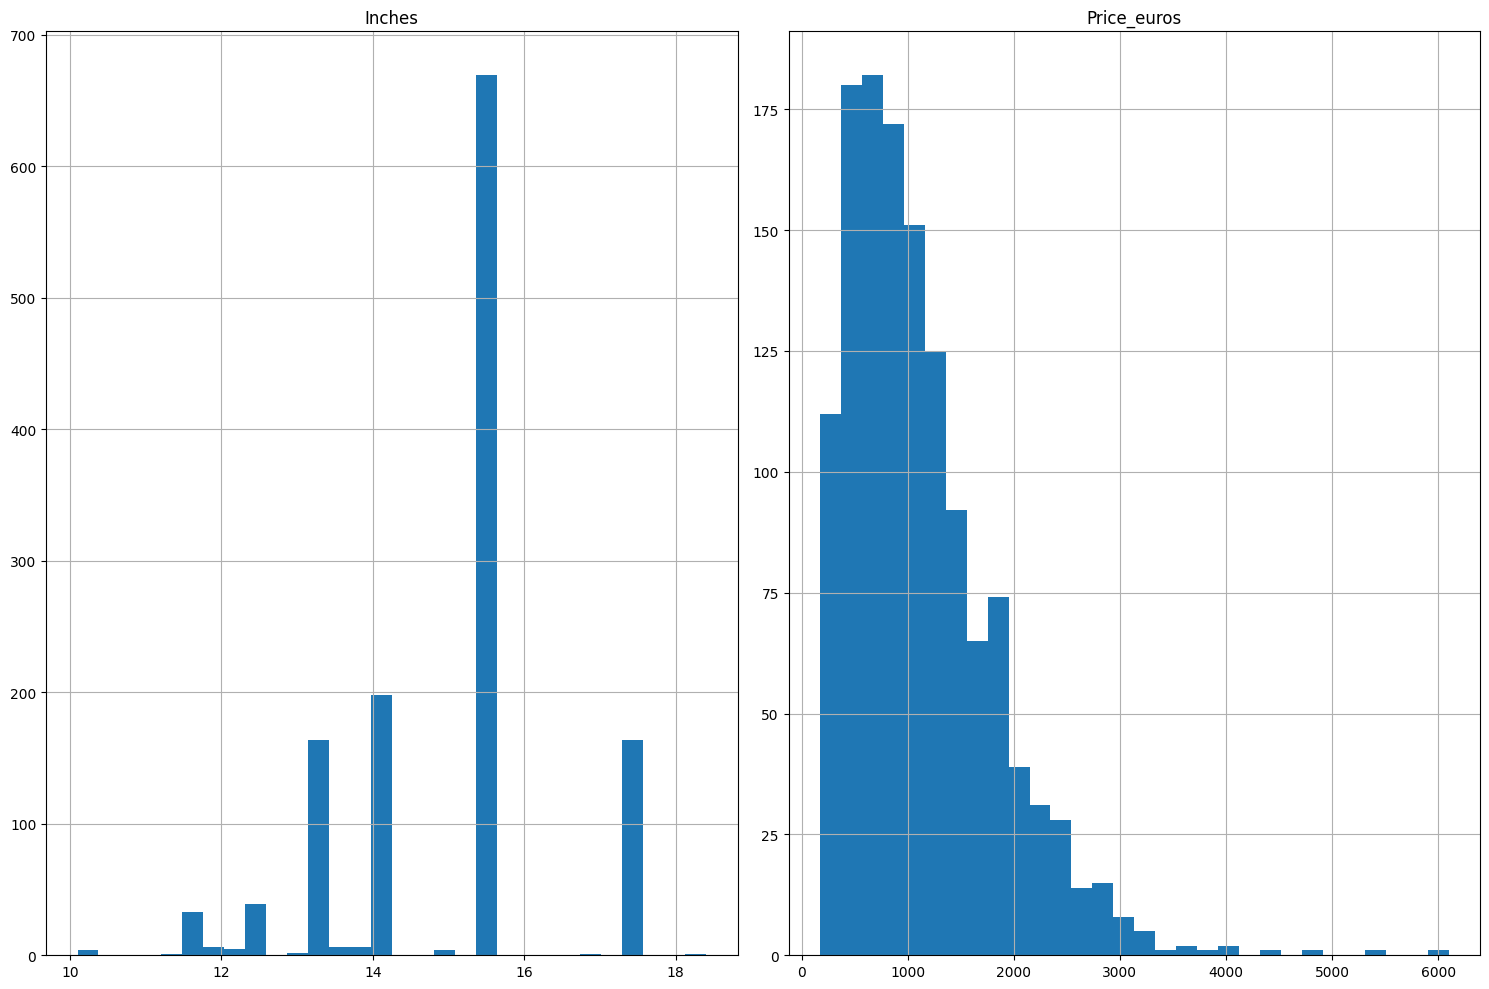

In [120]:
df.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

## Price Distribution

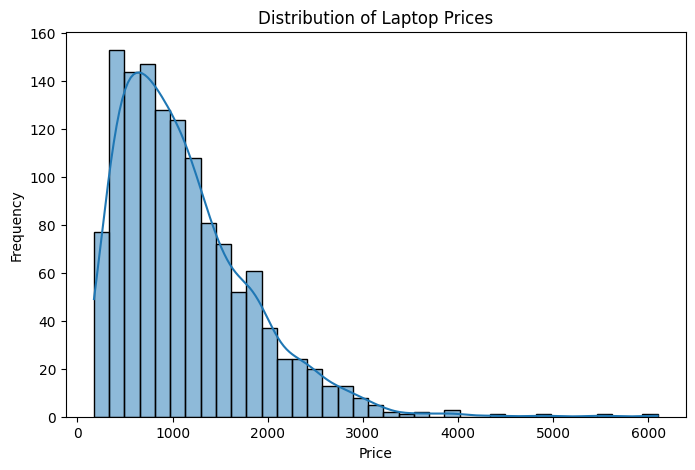

In [121]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price_euros"], kde=True)
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Company Distribution

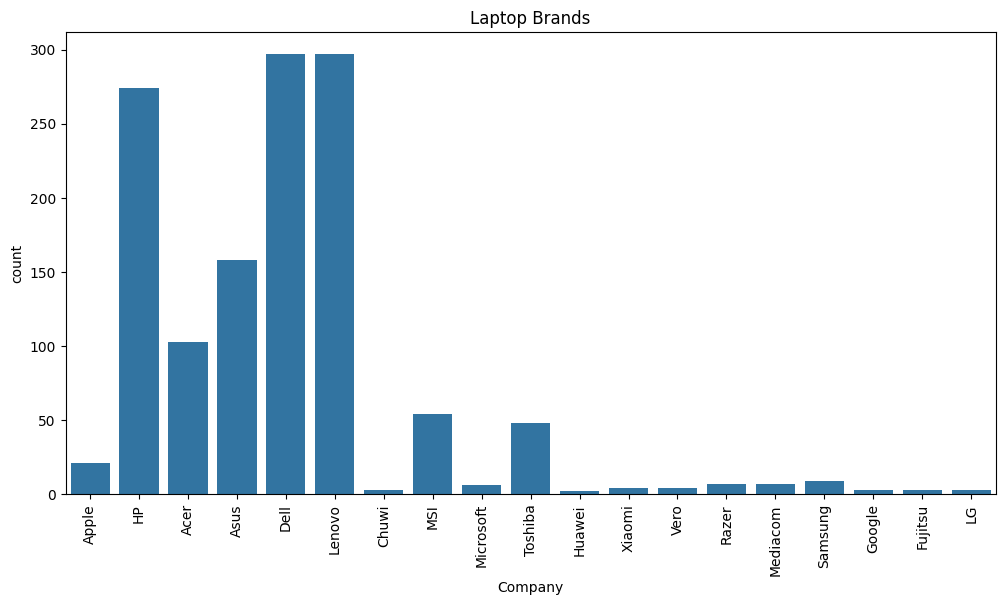

In [122]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Company")
plt.xticks(rotation=90)
plt.title("Laptop Brands")
plt.show()

## Company vs Price

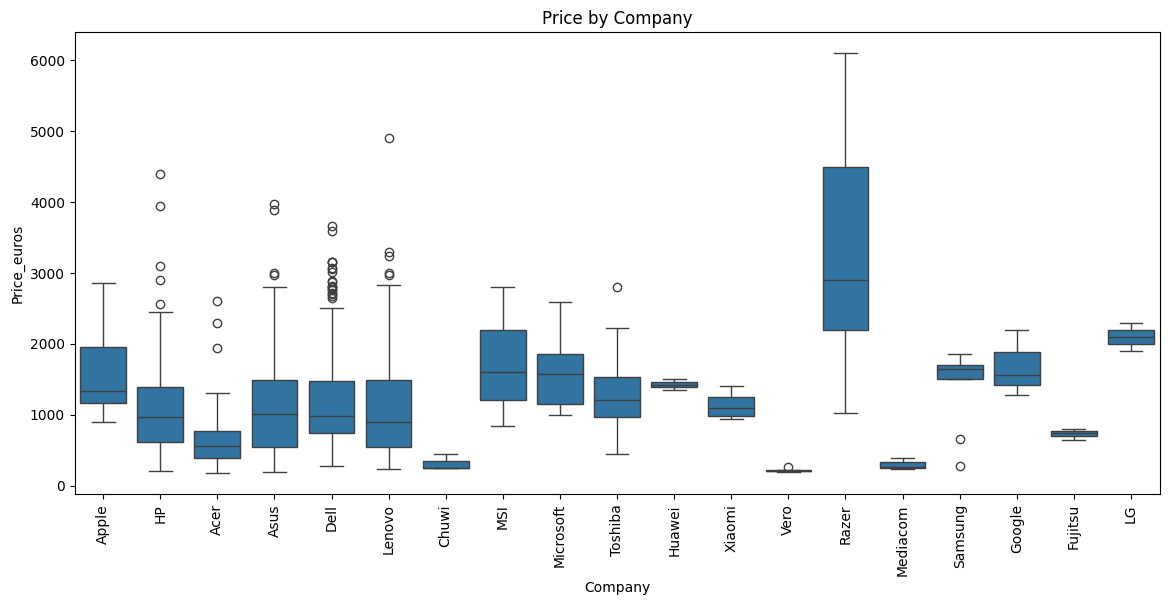

In [123]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="Company", y="Price_euros")
plt.xticks(rotation=90)
plt.title("Price by Company")
plt.show()

# 7. Feature Engineering

## Ram / Weight Cleanup

In [124]:
df["Ram_GB"] = df["Ram"].str.replace("GB", "").astype(int)
df["Weight_Kg"] = df["Weight"].str.replace("kg", "").astype(float)
df.drop(columns=['Ram', 'Weight'], inplace=True)

## Storage Feature Engineering

In [125]:
df['SSD'] = 0
df['HDD'] = 0
df['Flash_Storage'] = 0
df['Hybrid'] = 0

for i in range(len(df)):
    memory = df.loc[i, 'Memory']
    parts = re.split(r'\s*\+\s*', memory.strip())

    for part in parts:
        part = part.strip()
        size = 0

        if 'TB' in part:
            size = float(part.split('TB')[0]) * 1024
        elif 'GB' in part:
            size = float(part.split('GB')[0])

        if 'SSD' in part:
            df.loc[i, 'SSD'] = size
        elif 'HDD' in part:
            df.loc[i, 'HDD'] = size
        elif 'Flash Storage' in part:
            df.loc[i, 'Flash_Storage'] = size
        elif 'Hybrid' in part:
            df.loc[i, 'Hybrid'] = size

df['Total_Storage'] = df['SSD'] + df['HDD'] + df['Flash_Storage'] + df['Hybrid']
df.drop(columns=['Memory'], inplace=True)

## Screen Features

In [126]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touch' in x else 0)
df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)
df['X_res'] = df['ScreenResolution'].str.extract(r'(\d+)x').astype(int)
df['Y_res'] = df['ScreenResolution'].str.extract(r'x(\d+)').astype(int)
df['PPI'] = (np.sqrt(df['X_res'] ** 2 + df['Y_res'] ** 2)) / df['Inches']
df.drop(columns=['ScreenResolution', 'Inches', 'X_res', 'Y_res'], inplace=True)

## CPU Feature Engineering

In [127]:
df['Cpu_Name'] = df['Cpu'].apply(lambda x: " ".join(x.split()[:3]))

def processor(text):
    if text == 'Intel Core i7':
        return 'Intel Core i7'
    elif text == 'Intel Core i5':
        return 'Intel Core i5'
    elif text == 'Intel Core i3':
        return 'Intel Core i3'
    elif text.startswith('AMD'):
        return 'AMD'
    else:
        return 'Other'

df['CPU_Brand'] = df['Cpu_Name'].apply(processor)
df.drop(columns=['Cpu', 'Cpu_Name'], inplace=True)

## GPU Feature Engineering

In [128]:
df['GPU_Brand'] = df['Gpu'].apply(lambda x: x.split()[0])
df.drop(columns=['Gpu'], inplace=True)

## Operating System Feature Engineering

In [129]:
def operating_system(text):
    if 'Windows' in text:
        return 'Windows'
    elif 'Mac' in text:
        return 'Mac'
    elif 'Linux' in text:
        return 'Linux'
    else:
        return 'Others'

df['OS'] = df['OpSys'].apply(operating_system)
df.drop(columns=['OpSys'], inplace=True)

## Post Feature Engineering Visualization

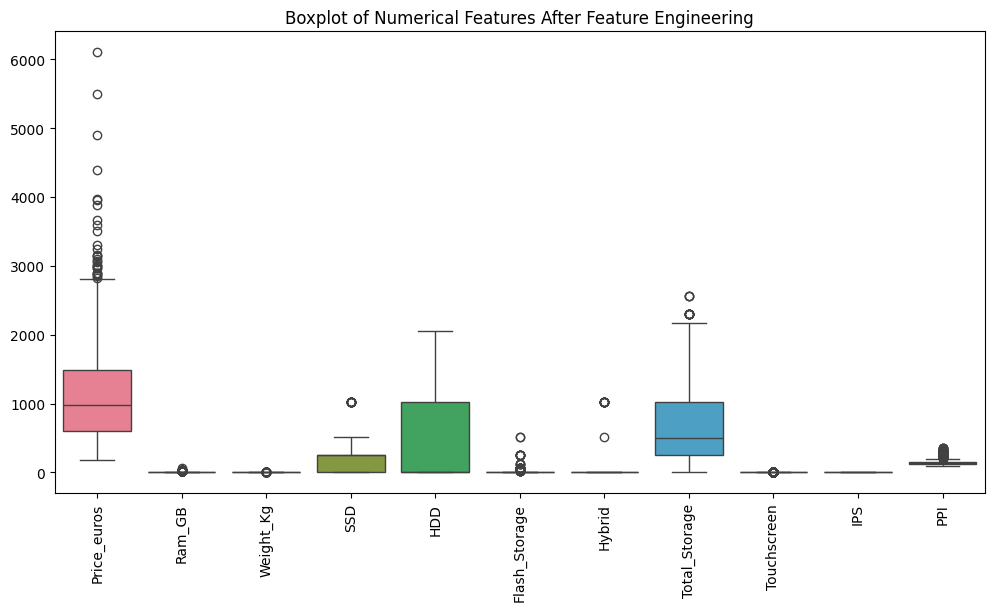

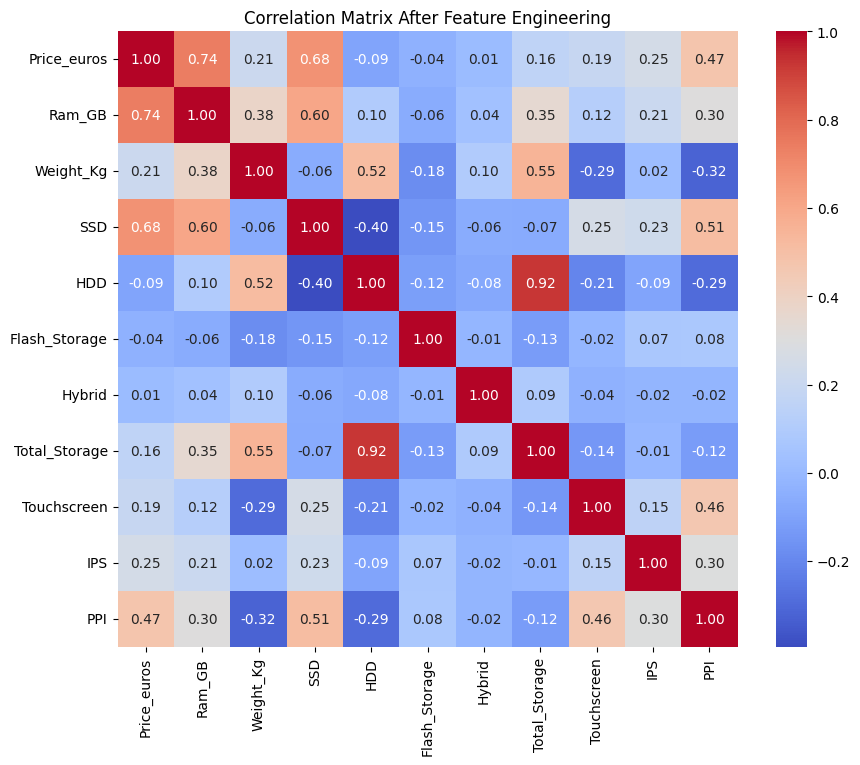

In [130]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features After Feature Engineering")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix After Feature Engineering")
plt.show()

# 8. Data Preparation for Modeling

## Find Categorical Columns for One-Hot Encoding

In [131]:
cat_cols = df.select_dtypes(include='object').columns
print("Categorical Columns for One-Hot Encoding:")
print(cat_cols)

Categorical Columns for One-Hot Encoding:
Index(['Company', 'TypeName', 'CPU_Brand', 'GPU_Brand', 'OS'], dtype='object')


## One-Hot Encoding

In [132]:
if len(cat_cols) > 0:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    print("One-hot encoding applied. New DataFrame shape:", df.shape)
else:
    print("No categorical columns found for one-hot encoding.")

One-hot encoding applied. New DataFrame shape: (1303, 44)


## Features and Target

In [133]:
X = df.drop("Price_euros", axis=1)
y = df["Price_euros"]

X.columns = (
    X.columns
      .str.replace('[', '', regex=False)
      .str.replace(']', '', regex=False)
      .str.replace('<', '', regex=False)
      .str.replace(' ', '_', regex=False)
      .str.replace('=', '_', regex=False)
      .str.replace('/', '_', regex=False)
      .str.replace('(', '', regex=False)
      .str.replace(')', '', regex=False)
      .str.replace('&', '', regex=False)
      .str.replace(':', '', regex=False)
      .str.replace(',', '', regex=False)
)

feature_names = X.columns.tolist()

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("First 5 feature names:", feature_names[:5])

Features (X) shape: (1303, 43)
Target (y) shape: (1303,)
First 5 feature names: ['Ram_GB', 'Weight_Kg', 'SSD', 'HDD', 'Flash_Storage']


## Train Test Split

In [135]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training Data (X_train) shape:", X_train.shape)
print("Testing Data (X_test) shape:", X_test.shape)
print("Training Target (y_train) shape:", y_train.shape)
print("Testing Target (y_test) shape:", y_test.shape)

Training Data (X_train) shape: (1042, 43)
Testing Data (X_test) shape: (261, 43)
Training Target (y_train) shape: (1042,)
Testing Target (y_test) shape: (261,)


## Standard Scaling

In [136]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save Scaler
joblib.dump(scaler, "Scaler.pkl")

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Scaler saved to Scaler.pkl")

X_train_scaled shape: (1042, 43)
X_test_scaled shape: (261, 43)
Scaler saved to Scaler.pkl


# 9. Model Training and Evaluation

## Create Models

In [137]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective="reg:squarederror"),
}

## Train Models & Calculate Metrics

In [138]:
results = []
trained_models = {}

for name, model in models.items():

    print("=" * 60)
    print("Training :", name)

    if name == "Linear Regression":

        model.fit(X_train_scaled, y_train)

        prediction = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        prediction = model.predict(X_test)

    trained_models[name] = model

    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))

    r2 = r2_score(y_test, prediction)

    mape = np.mean(np.abs((y_test - prediction) / y_test)) * 100

    accuracy = 100 - mape

    results.append([name, mae, rmse, r2, mape, accuracy])

Training : Linear Regression
Training : Decision Tree
Training : Random Forest
Training : Extra Trees
Training : Gradient Boosting
Training : XGBoost


## Results Table

In [139]:
results = pd.DataFrame(results,columns=["Model","MAE", "RMSE","R2 Score","MAPE","Accuracy"])

results = results.sort_values(by="R2 Score",ascending=False)
display(results)

,Model,MAE,RMSE,R2 Score,MAPE,Accuracy
5,XGBoost,174.383255,286.216866,0.838717,16.290678,83.709322
2,Random Forest,184.127353,311.494131,0.808971,17.061937,82.938063
4,Gradient Boosting,194.744885,317.041382,0.802107,18.706490,81.293510
1,Decision Tree,213.849406,330.064809,0.785515,19.971593,80.028407
0,Linear Regression,235.429789,341.587969,0.770277,23.902808,76.097192
3,Extra Trees,194.324604,361.184547,0.743163,17.507331,82.492669


## Best Model

In [140]:
best_model_name = results.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : XGBoost


## Model Comparison Graph

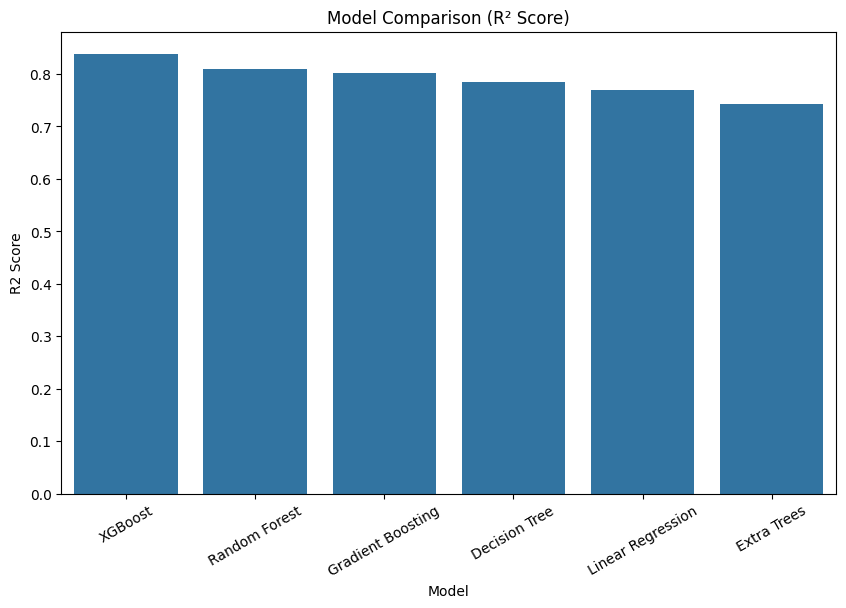

In [141]:
plt.figure(figsize=(10,6))
sns.barplot(data=results,x="Model",y="R2 Score")
plt.xticks(rotation=30)
plt.title("Model Comparison (R² Score)")
plt.show()

## MAE Comparison

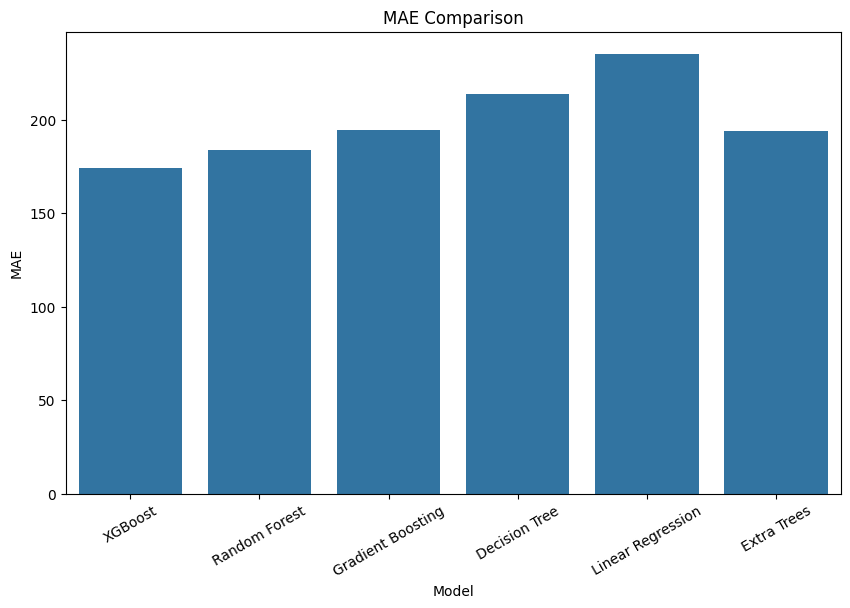

In [142]:
plt.figure(figsize=(10,6))
sns.barplot(data=results, x="Model", y="MAE")
plt.xticks(rotation=30)
plt.title("MAE Comparison")
plt.show()

# 10. Hyperparameter Tuning

## Hyperparameter Tuning Setup

In [143]:
param_grids = {
    "XGBoost": {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5],
        'gamma': [0, 0.1, 0.2, 0.3],
    },

    "Random Forest": {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 5, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    },

    "Extra Trees": {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 5, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    },

    "Gradient Boosting": {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [2, 3, 4, 5],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0],
    },
}

if best_model_name in param_grids:

    tuning_estimator = (
        type(models[best_model_name])(random_state=42)
        if best_model_name != "XGBoost"
        else XGBRegressor(objective='reg:squarederror', random_state=42)
    )

    param_grid = param_grids[best_model_name]

else:

    print(f"No tuning grid defined for '{best_model_name}', defaulting to XGBoost.")

    best_model_name = "XGBoost"

    tuning_estimator = XGBRegressor(objective='reg:squareenerror',random_state=42)

    param_grid = param_grids["XGBoost"]


## Randomized Search for Hyperparameter Tuning

In [144]:
random_search = RandomizedSearchCV(
    estimator=tuning_estimator,
    param_distributions=param_grid,
    n_iter=30,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

print("Best Parameters :", random_search.best_params_)
print("Best R² Score :", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters : {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best R² Score : 0.8356883551083827


## Best Model Evaluation (After Tuning)

In [145]:
best_model = random_search.best_estimator_

prediction = best_model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, prediction)))
print("R2 Score :", r2_score(y_test, prediction))

MAE : 178.88535006936027
RMSE : 302.0455506536874
R2 Score : 0.8203844252640796


## Cross Validation

In [146]:
scores = cross_val_score(best_model,X_train,y_train,cv=5,scoring='r2',n_jobs=-1)
print("Cross Validation R² Scores")

print(scores)

print("Average Cross Validation R² :", scores.mean())

print("Cross Validation Standard Deviation :", scores.std())

Cross Validation R² Scores
[0.85275759 0.85102732 0.85583191 0.80657811 0.81224685]
Average Cross Validation R² : 0.8356883551083827
Cross Validation Standard Deviation : 0.02158386482655429


## Final Evaluation Metrics

In [147]:
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)

mse = mean_squared_error(y_test, pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, pred)

mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

accuracy = 100 - mape

print("=" * 50)

print("Model Evaluation")

print("=" * 50)

print(f"MAE      : {mae:.2f}")

print(f"RMSE     : {rmse:.2f}")

print(f"R² Score : {r2:.4f}")

print(f"MAPE     : {mape:.2f}%")

print(f"Accuracy : {accuracy:.2f}%")

Model Evaluation
MAE      : 178.89
RMSE     : 302.05
R² Score : 0.8204
MAPE     : 17.10%
Accuracy : 82.90%


# 11. Model Visualization and Saving

## Actual vs Predicted Price Visualization

,Actual Price,Predicted Price
0,1672.00,1378.069458
1,1149.00,1346.765381
2,499.00,437.649536
3,899.00,964.358582
4,1244.00,1523.259033
5,1398.99,1543.868896
6,719.00,660.958862
7,459.00,328.255127
8,1191.00,1581.098511
9,349.00,481.528809


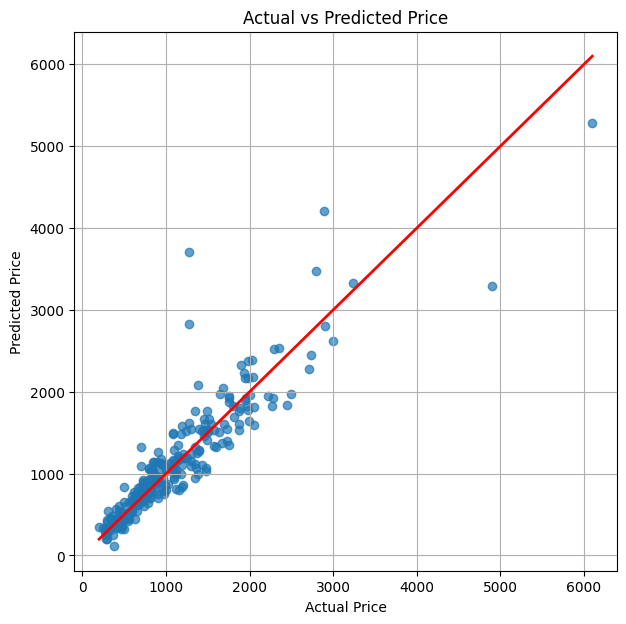

In [148]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": pred
})

display(comparison.head(10))

plt.figure(figsize=(7,7))

plt.scatter(y_test, pred, alpha=0.7)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.grid(True)

plt.show()

## Feature Importance

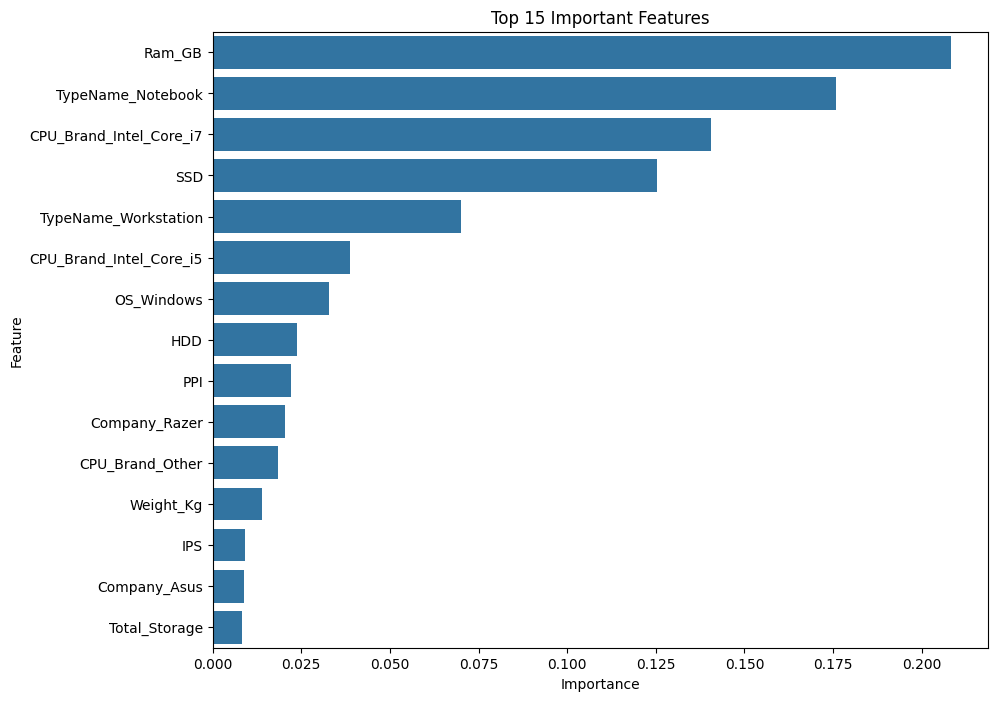

In [149]:
if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_,
}).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10,8))

    sns.barplot(data=importance.head(15), x="Importance", y="Feature")

    plt.title("Top 15 Important Features")

    plt.show()

else:

    print(f"{best_model_name} has no feature_importances_ attribute.")

## Learning Curve

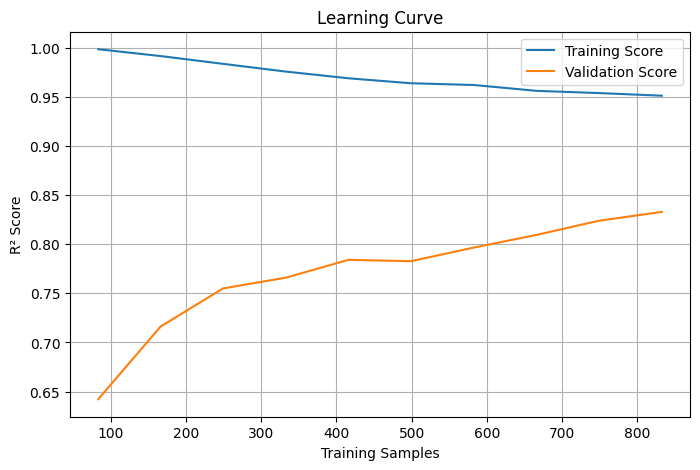

In [150]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1,1.0,10),
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)

test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, label="Training Score")

plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Samples")

plt.ylabel("R² Score")

plt.title("Learning Curve")

plt.legend()

plt.grid(True)

plt.show()

## Save Final Model

In [151]:
joblib.dump(best_model, "LaptopPriceModel.pkl")

joblib.dump(feature_names, "FeatureNames.pkl")

print("Best model saved as LaptopPriceModel.pkl")
print("Feature names saved as FeatureNames.pkl")

Best model saved as LaptopPriceModel.pkl
Feature names saved as FeatureNames.pkl


# 12. Model Deployment and Prediction Examples

## Single Prediction Example

In [153]:
sample = X.iloc[[25]]

prediction = best_model.predict(sample)

print("Predicted Price for sample (index 25) :", f"{prediction[0]:.2f}")

print("Actual Price for sample (index 25) :", f"{y.iloc[25]:.2f}")

Predicted Price for sample (index 25) : 521.62
Actual Price for sample (index 25) : 418.64


## Predict Random Samples

In [154]:
random_rows = X.sample(10, random_state=42)

predictions = best_model.predict(random_rows)

actual = y.loc[random_rows.index]

comparison = pd.DataFrame({"Actual Price": actual,"Predicted Price": predictions})

display(comparison)

,Actual Price,Predicted Price
479,1672.00,1378.069458
1022,1149.00,1346.765381
298,499.00,437.649536
1265,899.00,964.358582
774,1244.00,1523.259033
115,1398.99,1543.868896
582,719.00,660.958862
527,459.00,328.255127
380,1191.00,1581.098511
101,349.00,481.528809


## Load and Test the Saved Model

In [155]:
loaded_model = joblib.load('LaptopPriceModel.pkl')
loaded_scaler = joblib.load('Scaler.pkl')
loaded_feature_names = joblib.load('FeatureNames.pkl')

print("Model, scaler, and feature names loaded successfully.")

Model, scaler, and feature names loaded successfully.


In [157]:
# Create a sample data point for prediction (ensure it matches the feature structure)
# This is an example, replace with actual desired values

# Create a dummy DataFrame with all feature columns initialized to 0
sample_data = pd.DataFrame(0, index=[0], columns=loaded_feature_names)

# Populate some example values for the sample
sample_data['Ram_GB'] = 8
sample_data['Weight_Kg'] = 1.37
sample_data['SSD'] = 256
sample_data['HDD'] = 0
sample_data['Total_Storage'] = 256
sample_data['Touchscreen'] = 0
sample_data['IPS'] = 1
sample_data['PPI'] = 157.35
sample_data['Company_Lenovo'] = 1
sample_data['TypeName_Notebook'] = 1
sample_data['CPU_Brand_Intel_Core_i5'] = 1
sample_data['GPU_Brand_Intel'] = 1
sample_data['OS_Windows'] = 1

# Make sure the column order matches the training data
sample_data = sample_data[X.columns] # Use X.columns for ordering

# Scale the numerical features if the model used a scaler
# Note: Linear Regression model was scaled, others were not.
# This example assumes the best model is XGBoost, which did not use scaled data during training.
# If you were loading and testing Linear Regression, you would need to scale `sample_data`.

# If best_model_name was 'Linear Regression', then scale the sample:
# if best_model_name == 'Linear Regression':
#     sample_scaled = loaded_scaler.transform(sample_data)
# else:
#     sample_scaled = sample_data

# For simplicity, assuming the best model (XGBoost) does not require scaled input here based on previous steps.
# If a scaled model was chosen as best, this part would need adjustment.

predicted_price = loaded_model.predict(sample_data)

print(f"Predicted price for the sample laptop: {predicted_price[0]:.2f} euros")

Predicted price for the sample laptop: 1349.90 euros
